In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the raw dataset
df = pd.read_csv("../data/smartcare_ai_dataset_1000.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


In [4]:
data = df.copy()

print("Working copy created.")
print(f"Original shape: {df.shape}")
print(f"Working copy shape: {data.shape}")

Working copy created.
Original shape: (1000, 33)
Working copy shape: (1000, 33)


In [5]:
data["readmitted_30_days"].value_counts()

readmitted_30_days
0    747
1    253
Name: count, dtype: int64

In [6]:
data["readmitted_30_days"].value_counts(normalize=True) * 100

readmitted_30_days
0    74.7
1    25.3
Name: proportion, dtype: float64

In [7]:
data[["record_id", "patient_id"]].head()

,record_id,patient_id
0,1,P10001
1,2,P10002
2,3,P10003
3,4,P10004
4,5,P10005


In [8]:
print("Unique record IDs:", data["record_id"].nunique())
print("Unique patient IDs:", data["patient_id"].nunique())

Unique record IDs: 1000
Unique patient IDs: 1000


In [9]:
data[[
    "no_show",
    "readmitted_30_days",
    "disease_risk_level"
]].head()

,no_show,readmitted_30_days,disease_risk_level
0,0,0,High
1,0,0,Medium
2,1,0,Medium
3,0,0,Medium
4,0,0,Medium


In [10]:
target = "readmitted_30_days"

In [11]:
data["readmitted_30_days"].value_counts()
data["readmitted_30_days"].value_counts(normalize=True) * 100
print("Unique record IDs:", data["record_id"].nunique())
print("Unique patient IDs:", data["patient_id"].nunique())


data[[
    "no_show",
    "readmitted_30_days",
    "disease_risk_level"
]].head()

Unique record IDs: 1000
Unique patient IDs: 1000


,no_show,readmitted_30_days,disease_risk_level
0,0,0,High
1,0,0,Medium
2,1,0,Medium
3,0,0,Medium
4,0,0,Medium


In [12]:
data["readmitted_30_days"].value_counts()


data["readmitted_30_days"].value_counts(normalize=True) * 100

readmitted_30_days
0    74.7
1    25.3
Name: proportion, dtype: float64

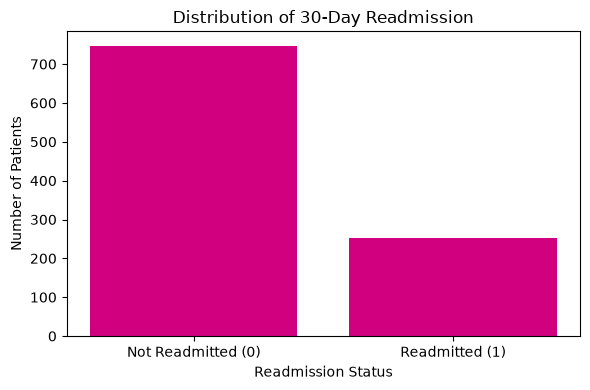

In [13]:
import matplotlib.pyplot as plt

target_counts = data["readmitted_30_days"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Not Readmitted (0)", "Readmitted (1)"],
    target_counts.values,
    color="#D1007F"
)

plt.title("Distribution of 30-Day Readmission")
plt.ylabel("Number of Patients")
plt.xlabel("Readmission Status")

plt.tight_layout()
plt.show()

## Target Variable Distribution

The target variable `readmitted_30_days` contains two classes:

- `0` – Patient was not readmitted within 30 days.
- `1` – Patient was readmitted within 30 days.

The dataset contains 74.7% non-readmitted cases and 25.3% readmitted cases. This indicates a moderate class imbalance, with the non-readmitted class representing the majority of observations.

Because identifying readmitted patients is an important objective of the system, model evaluation will not rely solely on accuracy. Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix will also be considered.

In [14]:
pd.crosstab(
    data["admitted"],
    data["room_type"],
    dropna=False
)

pd.crosstab(
    data["admitted"],
    data["room_type"],
    normalize="index",
    dropna=False
)

room_type,General Ward,ICU,Private Room,NaN
admitted,,,,
0,0.000000,0.000000,0.0,1.000000
1,0.157576,0.027273,0.1,0.715152


## Room Type Missing-Value Investigation

The `room_type` attribute contains a substantial proportion of missing values. A cross-tabulation between `admitted` and `room_type` was performed to investigate whether missing room types could be explained solely by non-admission.

The analysis showed that all non-admitted patients (`admitted = 0`) have missing room-type values. However, missing room-type values are also present among admitted patients, where approximately 71.52% of admitted records have no recorded room type.

Therefore, missing `room_type` values cannot be assumed to represent non-admission. The missing values will be retained and represented as an `"Unknown"` category during categorical preprocessing. This approach preserves the records while allowing the machine learning model to distinguish missing room information from explicitly recorded room types.

In [15]:
missing_summary = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Missing Percentage": (data.isnull().sum() / len(data)) * 100
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Values", ascending=False)

missing_summary

,Missing Values,Missing Percentage
room_type,906,90.6


In [16]:
# Handle missing values in room_type
data["room_type"] = data["room_type"].fillna("Unknown")

# Verify
print("Missing room_type values:", data["room_type"].isnull().sum())
print("\nRoom type distribution:")
print(data["room_type"].value_counts())

Missing room_type values: 0

Room type distribution:
room_type
Unknown         906
General Ward     52
Private Room     33
ICU               9
Name: count, dtype: int64


In [17]:
# Identify categorical columns
categorical_columns = data.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
for column in categorical_columns:
    print("-", column)

Categorical columns:
- patient_id
- gender
- blood_group
- department
- diagnosis
- appointment_date
- appointment_status
- room_type
- payment_status
- payment_method
- disease_risk_level


C:\Users\rusir\AppData\Local\Temp\ipykernel_4412\3556139314.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=["object"]).columns.tolist()


In [18]:
print("\nNumber of categorical columns:", len(categorical_columns))

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(data[column].unique())


Number of categorical columns: 11

--- patient_id ---
<ArrowStringArray>
['P10001', 'P10002', 'P10003', 'P10004', 'P10005', 'P10006', 'P10007',
 'P10008', 'P10009', 'P10010',
 ...
 'P10991', 'P10992', 'P10993', 'P10994', 'P10995', 'P10996', 'P10997',
 'P10998', 'P10999', 'P11000']
Length: 1000, dtype: str

--- gender ---
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

--- blood_group ---
<ArrowStringArray>
['A-', 'B-', 'B+', 'AB-', 'O+', 'A+', 'AB+', 'O-']
Length: 8, dtype: str

--- department ---
<ArrowStringArray>
[   'General Medicine',         'Orthopedics',          'Cardiology',
           'Neurology',          'Pediatrics', 'Laboratory Services',
           'Radiology']
Length: 7, dtype: str

--- diagnosis ---
<ArrowStringArray>
[        'Migraine',         'Diabetes',        'Back Pain',
           'Asthma',     'Hypertension',         'Fracture',
 'Kidney Infection',            'Fever',       'Chest Pain',
        'Pneumonia']
Length: 10, dtype: str

--- appointm

In [19]:
for column in [
    "gender",
    "blood_group",
    "department",
    "diagnosis",
    "appointment_status",
    "room_type",
    "payment_status",
    "payment_method"
]:
    print(f"\n{'='*50}")
    print(column)
    print(data[column].value_counts(dropna=False))


gender
gender
Male      501
Female    499
Name: count, dtype: int64

blood_group
blood_group
AB-    136
A-     135
O-     135
B+     132
AB+    122
A+     120
B-     112
O+     108
Name: count, dtype: int64

department
department
General Medicine       159
Cardiology             158
Neurology              148
Orthopedics            141
Radiology              140
Pediatrics             138
Laboratory Services    116
Name: count, dtype: int64

diagnosis
diagnosis
Pneumonia           115
Fever               107
Migraine            104
Back Pain           104
Fracture            104
Kidney Infection    101
Diabetes             97
Asthma               92
Hypertension         89
Chest Pain           87
Name: count, dtype: int64

appointment_status
appointment_status
No-Show      495
Completed    380
Scheduled     72
Cancelled     53
Name: count, dtype: int64

room_type
room_type
Unknown         906
General Ward     52
Private Room     33
ICU               9
Name: count, dtype: int64

paymen

In [20]:
model_data = data.copy()

In [21]:
model_data["appointment_date"] = pd.to_datetime(
    model_data["appointment_date"],
    errors="coerce"
)

In [22]:
model_data["appointment_year"] = model_data["appointment_date"].dt.year
model_data["appointment_month"] = model_data["appointment_date"].dt.month
model_data["appointment_day"] = model_data["appointment_date"].dt.day
model_data["appointment_dayofweek"] = model_data["appointment_date"].dt.dayofweek

In [23]:
model_data = model_data.drop(columns=[
    "appointment_date",
    "record_id",
    "patient_id",
    "no_show",
    "disease_risk_level"
])

In [24]:
print("Original columns:", len(data.columns))
print("Model columns:", len(model_data.columns))

model_data.head()

Original columns: 33
Model columns: 32


,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,readmitted_30_days,appointment_year,appointment_month,appointment_day,appointment_dayofweek
0,53,Male,A-,General Medicine,Migraine,10,1,0,Completed,0,Unknown,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,2025,4,10,3
1,26,Male,B-,General Medicine,Diabetes,2,3,1,Completed,0,Unknown,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,2025,5,15,3
2,22,Male,B+,Orthopedics,Back Pain,22,7,1,No-Show,0,Unknown,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,0,2025,7,9,2
3,44,Female,AB-,Cardiology,Asthma,16,1,0,Completed,0,Unknown,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,2025,10,16,3
4,51,Female,O+,Neurology,Hypertension,12,4,0,Scheduled,0,Unknown,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,2025,12,18,3


In [25]:
model_data.dtypes

age                               int64
gender                              str
blood_group                         str
department                          str
diagnosis                           str
waiting_days                      int64
previous_appointments             int64
missed_previous_appointments      int64
appointment_status                  str
admitted                          int64
room_type                           str
length_of_stay_days               int64
previous_admissions               int64
systolic_bp                       int64
diastolic_bp                      int64
blood_sugar_mg_dl                 int64
cholesterol_mg_dl                 int64
bmi                             float64
lab_tests_count                   int64
treatments_count                  int64
consultation_fee_lkr              int64
room_charge_lkr                   int64
lab_charge_lkr                    int64
medicine_charge_lkr               int64
total_bill_lkr                    int64


In [26]:
# Separate input features and target variable

X = model_data.drop(columns=["readmitted_30_days"])
y = model_data["readmitted_30_days"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1000, 31)
Target shape: (1000,)


In [27]:
print("Target variable:", y.name)
print("\nFeature columns:")
print(X.columns.tolist())

Target variable: readmitted_30_days

Feature columns:
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'appointment_status', 'admitted', 'room_type', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'payment_status', 'payment_method', 'appointment_year', 'appointment_month', 'appointment_day', 'appointment_dayofweek']


Think of it simply:

X = information we give the AI

age
gender
diagnosis
blood pressure
BMI
previous admissions
...

y = answer we want the AI to learn

readmitted_30_days

So conceptually:

X ───────────────► Machine Learning Model ───────────────► y
Patient information                                  Readmission

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (800, 31)
Testing features: (200, 31)
Training target: (800,)
Testing target: (200,)


In [29]:
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

Categorical features:
['gender', 'blood_group', 'department', 'diagnosis', 'appointment_status', 'room_type', 'payment_status', 'payment_method']

Number of categorical features: 8

Numerical features:
['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'admitted', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'appointment_year', 'appointment_month', 'appointment_day', 'appointment_dayofweek']

Number of numerical features: 23


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [31]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (800, 65)
Processed testing shape: (200, 65)


In [32]:
print("Training data type:", type(X_train_processed))
print("Testing data type:", type(X_test_processed))

print("\nMissing values in training:",
      np.isnan(X_train_processed).sum())

print("Missing values in testing:",
      np.isnan(X_test_processed).sum())

print("\nTraining shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training data type: <class 'numpy.ndarray'>
Testing data type: <class 'numpy.ndarray'>

Missing values in training: 0
Missing values in testing: 0

Training shape: (800, 65)
Testing shape: (200, 65)


In [33]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
readmitted_30_days
0    598
1    202
Name: count, dtype: int64

Testing target distribution:
readmitted_30_days
0    149
1     51
Name: count, dtype: int64


In [34]:
print("Training target percentages:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target percentages:")
print(y_test.value_counts(normalize=True) * 100)

Training target percentages:
readmitted_30_days
0    74.75
1    25.25
Name: proportion, dtype: float64

Testing target percentages:
readmitted_30_days
0    74.5
1    25.5
Name: proportion, dtype: float64


In [35]:
import joblib

joblib.dump(preprocessor, "../models/preprocessor.joblib")

print("✅ Preprocessor saved successfully.")

✅ Preprocessor saved successfully.


In [36]:
np.isnan(X_train_processed).sum()

np.int64(0)

In [37]:
y_train.value_counts(normalize=True) * 100

readmitted_30_days
0    74.75
1    25.25
Name: proportion, dtype: float64

In [38]:
joblib.dump(preprocessor, "../models/preprocessor.joblib")

['../models/preprocessor.joblib']